Data su dva skupa podataka, jedan sa m merenja i drugi sa n merenja. Prvi skup se odnosi na gustine fluksa merene u slucajnim pozicijama na nebu, a drugi na gustine fluksa merene u pozicijama specificnih grupa galaksije (gustina fluksa je S[mJy]).

1. zadatak: Podaci su dati u obliku histograma. Rekonstruinsati sirove uzorke i objasniti zasto je ovaj korak neophodan (moze se koristiti npr. np.repeat). Iscrtati pripadajuce grafike.

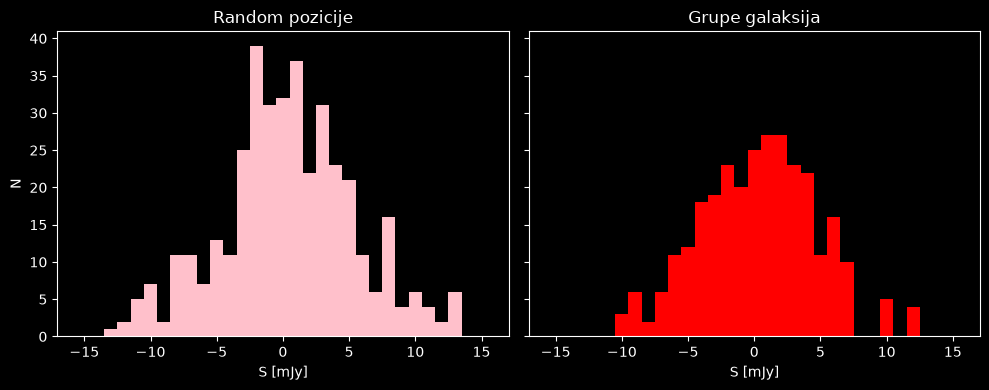

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

#ucitavanje podataka
ks_uzorci=np.genfromtxt('gr.dat', skip_header=2, skip_footer=2)

#izvlacenje kolona iz gr.dat
mJy, G, R=ks_uzorci.T

#rekonstrukcija sirovih uzoraka iz histogramskih
#np.repeat ponavlja svaku vrednost iz mJy
G_uzorak=np.repeat(mJy, G.astype(int))
R_uzorak=np.repeat(mJy, R.astype(int))

#grafici
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(G_uzorak, bins=np.arange(min(mJy)-0.5, max(mJy)+1.5, 1), color='pink')
axes[0].set_title('Random pozicije')
axes[0].set_xlabel('S [mJy]')
axes[0].set_ylabel('N')

axes[1].hist(R_uzorak, bins=np.arange(min(mJy)-0.5, max(mJy)+1.5, 1), color='red')
axes[1].set_title('Grupe galaksija')
axes[1].set_xlabel('S [mJy]')

plt.tight_layout()
plt.show()


2. Koristeci se Kolmogorov-Smirnov dvouzorackim testom, treba ispitati hipotezu da li postoji ekces gustine fluksa na ne-slucajnm pozicijama. Dodatno proveriti hipotezu koristeci se U-testom. Interpretirati.

In [17]:
#sve ostalo koristim iz prvog zadatka
from scipy.stats import mannwhitneyu

#kolmogorov-smirnov dvouzoracki test
D, pD=ks_2samp(G_uzorak, R_uzorak, alternative='less')

#U test
U, pU=mannwhitneyu(G_uzorak, R_uzorak, alternative='less')

#print rezultata
print('Kolmogorov-Smirnov test: D=%.2g, p=%.2g' % (D, pD))
print('U test: U=%.2g, p=%.2g' % (U, pU))

Kolmogorov-Smirnov test: D=0.067, p=0.21
U test: U=5.7e+04, p=0.6


Kako su p vrednosti kod oba testa veca od nivoa znacajnosti, $\alpha=0.05$, ne odbacujemo nultu hipotezu.
Na osnovu ovog uzorka ne uocavamo eksces gustine fluksa kod grupa galaksija.